In [3]:
from typing import Dict, Tuple, List, Optional, Callable
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Consistent color definitions used across SynOmics visualizations
DATA_COLORS = {"real": "#4c72b0", "synthetic": "#dd8452"}
PVAL_BIN_COLORS_DEFAULT = ["#d62728", "#ff7f0e", "#1f77b4", "#cccccc"]  # red, orange, blue, gray


def _shorten_hallmark_term(term: str) -> str:
    """
    Convert MSigDB Hallmark term into a shorter pathway label for y-axis.

    Args:
        term (str): Raw Hallmark term.

    Returns:
        str: Shortened label.

    Raises:
        ValueError: If term is empty.
    """
    if term is None or str(term).strip() == "":
        raise ValueError("term must be a non-empty string.")

    t = str(term).strip().upper()
    if t.startswith("HALLMARK_"):
        t = t.replace("HALLMARK_", "", 1)

    mapping = {
        "INTERFERON_ALPHA_RESPONSE": r"IFN$\alpha$",
        "INTERFERON_GAMMA_RESPONSE": r"IFN$\gamma$",
        "IL6_JAK_STAT3_SIGNALING": "IL6–JAK–STAT3",
        "INFLAMMATORY_RESPONSE": "Inflammatory",
        "TGF_BETA_SIGNALING": r"TGF-$\beta$",
        "DNA_REPAIR": "DNA repair",
        "ALLOGRAFT_REJECTION": "Allograft rejection",
        "COMPLEMENT": "Complement",
        "EPITHELIAL_MESENCHYMAL_TRANSITION": "Epithelial",
        "WNT_BETA_CATENIN_SIGNALING": r"WNT/$\beta$-catenin",
    }
    return mapping.get(t, t.replace("_", " ").title())


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Strip whitespace from dataframe column names.

    Args:
        df (pd.DataFrame): Input dataframe.

    Returns:
        pd.DataFrame: Dataframe with stripped columns.
    """
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def _resolve_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    """
    Resolve a column name from a list of candidate aliases.

    Args:
        df (pd.DataFrame): Input dataframe.
        candidates (List[str]): Candidate column names in priority order.

    Returns:
        Optional[str]: Matched column name if found.
    """
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None


def plot_pathway(
    ssGSEA_comparison: Dict[str, pd.DataFrame],
    ref_pathway_list: List[str],
    highlight_pathways: Optional[List[str]] = None,
    origin_name: str = "Origin",
    term_col: str = "Term",
    pval_col: str = "adj_pvalues",
    diff_col: str = "Diff_NES",
    shorten_terms: bool = True,
    term_formatter: Optional[Callable[[str], str]] = None,
    pval_bin_colors: List[str] = PVAL_BIN_COLORS_DEFAULT,
    dataset_colors: Optional[Dict[str, str]] = None,
    figsize: Optional[Tuple[float, float]] = None,
    fig_width_min: float = 14.0,
    bubble_size: float = 170.0,
    title_pad: float = 14.0,
    dataset_strip_y: float = 1.01,
    dataset_strip_lw: float = 4.0,
    dataset_strip_pad: float = 0.0,
    show: bool = True,
    save_path: Optional[str] = None,
    return_dataframe: bool = True,
    allow_column_aliases: bool = True,
) -> Tuple[plt.Figure, Optional[pd.DataFrame]]:
    """
    Plot a pathway bubble scatter plot from ssGSEA comparison results (Term, Diff_NES, adjusted p-value).

    Args:
        ssGSEA_comparison (Dict[str, pd.DataFrame]): Mapping dataset name -> ssGSEA comparison DataFrame.
        ref_pathway_list (List[str]): Ordered list of pathways/terms to show.
        highlight_pathways (Optional[List[str]]): Pathways to highlight (bold + colored y-ticks).
        origin_name (str): Name of the reference dataset used to order pathways on the y-axis.
        term_col (str): Preferred column name for term/pathway.
        pval_col (str): Preferred column name for adjusted p-values / q-values.
        diff_col (str): Preferred column name for NES difference (groupA - groupB).
        shorten_terms (bool): If True, shorten Hallmark term labels for readability.
        term_formatter (Optional[Callable[[str], str]]): Custom formatting function for y-axis labels.
            If None and shorten_terms=True, uses _shorten_hallmark_term.
        pval_bin_colors (List[str]): Four colors for p-value bins [p<0.01, 0.01≤p<0.05, 0.05≤p<0.25, p≥0.25].
        dataset_colors (Optional[Dict[str, str]]): Mapping dataset name -> strip color under title.
        figsize (Optional[Tuple[float, float]]): If provided, use this figure size (inches) directly.
        fig_width_min (float): Minimum figure width if figsize is None.
        bubble_size (float): Scatter marker size.
        title_pad (float): Padding (points) between axis and title.
        dataset_strip_y (float): Strip y position in axes coordinates (1.0 is top border).
        dataset_strip_lw (float): Strip line width.
        dataset_strip_pad (float): Additional vertical offset added to dataset_strip_y (axes coords).
        show (bool): If True, call plt.show() before returning the figure.
        save_path (Optional[str]): If provided, save the figure to this path (dpi=300).
        return_dataframe (bool): If True return the concatenated dataframe used for plotting along with the Figure.
        allow_column_aliases (bool): If True, attempt to resolve common aliases for term/p-value/diff columns.

    Returns:
        Tuple[matplotlib.figure.Figure, Optional[pandas.DataFrame]]: The created matplotlib Figure and the DataFrame used for plotting.

    Raises:
        ValueError: If ssGSEA_comparison is empty.
        ValueError: If ref_pathway_list is empty.
        ValueError: If no dataset contains required columns and at least one requested pathway.
    """
    if not ssGSEA_comparison:
        raise ValueError("ssGSEA_comparison must not be empty.")
    if not ref_pathway_list:
        raise ValueError("ref_pathway_list must not be empty.")
    if highlight_pathways is None:
        highlight_pathways = []
    if term_formatter is None and shorten_terms:
        term_formatter = _shorten_hallmark_term

    datasets = list(ssGSEA_comparison.keys())
    all_data_to_plot: List[pd.DataFrame] = []
    found_any = False

    term_candidates = [term_col, "term", "Pathway", "pathway"]
    pval_candidates = [pval_col, "adj_pvalue", "adj.P.Val", "padj", "qvalue", "q-value", "FDR", "FDR q-val"]
    diff_candidates = [diff_col, "Diff_NES", "diff_nes", "NES_diff", "delta_NES", "NES", "nes"]

    for ds_name in datasets:
        df_ds = ssGSEA_comparison.get(ds_name)
        if df_ds is None or not isinstance(df_ds, pd.DataFrame):
            warnings.warn(f"Skipping {ds_name}: not a pandas DataFrame.")
            continue

        df_ds = _normalize_columns(df_ds)

        if allow_column_aliases:
            term_resolved = _resolve_column(df_ds, term_candidates)
            pval_resolved = _resolve_column(df_ds, pval_candidates)
            diff_resolved = _resolve_column(df_ds, diff_candidates)
        else:
            term_resolved = term_col if term_col in df_ds.columns else None
            pval_resolved = pval_col if pval_col in df_ds.columns else None
            diff_resolved = diff_col if diff_col in df_ds.columns else None

        missing = []
        if term_resolved is None:
            missing.append(term_col)
        if pval_resolved is None:
            missing.append(pval_col)
        if diff_resolved is None:
            missing.append(diff_col)

        if missing:
            warnings.warn(
                f"Skipping {ds_name}: missing required columns: {missing}. "
                f"Available columns: {list(df_ds.columns)}"
            )
            continue

        sub_df = df_ds[df_ds[term_resolved].isin(ref_pathway_list)].copy()
        if sub_df.empty:
            warnings.warn(f"Skipping {ds_name}: none of ref_pathway_list terms were found.")
            continue

        found_any = True

        sub_df = sub_df.rename(
            columns={
                term_resolved: "Term",
                pval_resolved: "adj_pvalues",
                diff_resolved: "Diff_NES",
            }
        )
        sub_df["Dataset"] = ds_name

        sub_df["adj_pvalues"] = pd.to_numeric(sub_df["adj_pvalues"], errors="coerce")
        sub_df["Diff_NES"] = pd.to_numeric(sub_df["Diff_NES"], errors="coerce").fillna(0.0)

        sub_df["-log10(qvalue)"] = -np.log10(sub_df["adj_pvalues"].clip(lower=np.nextafter(0, 1)))

        all_data_to_plot.append(sub_df[["Dataset", "Term", "adj_pvalues", "Diff_NES", "-log10(qvalue)"]])

    if not found_any:
        raise ValueError("No dataset contained required columns and at least one requested pathway.")

    df_plot = pd.concat(all_data_to_plot, ignore_index=True)

    present = set(df_plot["Term"].unique())
    y_terms = [p for p in ref_pathway_list if p in present]
    if not y_terms:
        raise ValueError("None of the pathways in ref_pathway_list were found after filtering.")

    # If origin dataset exists, reorder pathways by increasing adjusted p-value within origin
    origin_df = df_plot[df_plot["Dataset"] == origin_name].copy()
    if not origin_df.empty:
        origin_df = origin_df.sort_values(by="adj_pvalues", ascending=True, na_position="last")
        origin_sorted = origin_df["Term"].tolist()
        # keep ref_pathway_list coverage + order stability
        merged = []
        for t in origin_sorted + list(ref_pathway_list):
            if (t in ref_pathway_list) and (t in present) and (t not in merged):
                merged.append(t)
        y_terms = merged

    # Display labels (shortened)
    if term_formatter is not None:
        y_labels = [term_formatter(t) for t in y_terms]
    else:
        y_labels = list(y_terms)

    mapping = {term: idx for idx, term in enumerate(y_terms)}
    y_pos = np.arange(len(y_terms))

    max_abs_nes = np.nanmax(np.abs(df_plot["Diff_NES"].to_numpy(dtype=float)))
    if not np.isfinite(max_abs_nes) or max_abs_nes == 0:
        max_abs_nes = 1.0

    bins = [0, 0.01, 0.05, 0.25, 1.01]
    bin_labels = ["p<0.01", "0.01≤p<0.05", "0.05≤p<0.25", "p≥0.25"]
    color_map = dict(zip(bin_labels, pval_bin_colors))

    df_plot["pvalue_bin"] = pd.cut(
        df_plot["adj_pvalues"],
        bins=bins,
        labels=bin_labels,
        include_lowest=True,
        right=False,
    )

    n_cols = len(datasets)

    if figsize is None:
        fig_width = max(3.5 * n_cols + 2, fig_width_min)
        fig_height = max(0.6 * len(y_terms) + 3, 7)
        figsize = (fig_width, fig_height)

    fig, axes = plt.subplots(1, n_cols, figsize=figsize, sharey=True, sharex=True)
    axes_list = [axes] if n_cols == 1 else list(axes.flat)

    plt.subplots_adjust(left=0.28, right=0.88, top=0.88, bottom=0.08, wspace=0.18)

    highlight_set = set(highlight_pathways or [])

    for i, ds in enumerate(datasets):
        ax = axes_list[i]
        sub = df_plot[df_plot["Dataset"] == ds].copy()
        sub["y"] = sub["Term"].map(mapping)

        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10, color="grey", transform=ax.transAxes)
            ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
            ax.set_title(ds, fontsize=10, fontweight="bold", pad=title_pad)
            ax.tick_params(left=False, labelleft=False)
        else:
            bubble_colors = sub["pvalue_bin"].map(color_map).fillna("#cccccc")

            ax.scatter(
                x=sub["Diff_NES"],
                y=sub["y"],
                s=bubble_size,
                c=bubble_colors,
                edgecolor="k",
                linewidths=0.4,
                alpha=0.95,
                zorder=2,
            )

            ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.2, zorder=1)
            ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
            ax.set_xlabel(diff_col, fontsize=9, labelpad=6)

            ax.set_yticks(y_pos)
            ax.set_ylim(-0.5, len(y_terms) - 0.5)
            ax.invert_yaxis()
            ax.set_title(ds, fontsize=10, fontweight="bold", pad=title_pad)
            ax.grid(axis="y", linestyle="--", alpha=0.4)

            if i == 0:
                ax.set_yticklabels(y_labels, fontsize=9)
                ax.tick_params(axis="y", which="major", pad=6)
                for j, label in enumerate(ax.get_yticklabels()):
                    term = y_terms[j]
                    if term in highlight_set:
                        label.set_color(DATA_COLORS["real"])
                        label.set_fontweight("bold")
                    else:
                        label.set_color("black")
            else:
                ax.tick_params(left=False, labelleft=False)

        if dataset_colors is not None:
            strip_color = dataset_colors.get(ds, "#333333")
            y_strip = dataset_strip_y + dataset_strip_pad
            ax.plot(
                [0.08, 0.92],
                [y_strip, y_strip],
                transform=ax.transAxes,
                color=strip_color,
                lw=dataset_strip_lw,
                clip_on=False,
                solid_capstyle="round",
            )

    import matplotlib.patches as mpatches

    legend_patches = [mpatches.Patch(color=color_map[l], label=l) for l in bin_labels]
    axes_list[-1].legend(
        handles=legend_patches,
        title=pval_col,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8,
        title_fontsize=9,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0.03, 0.88, 0.98])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    df_plot["y"] = df_plot["Term"].map(mapping)
    df_plot = df_plot[["Dataset", "Term", "adj_pvalues", "Diff_NES", "-log10(qvalue)", "y", "pvalue_bin"]]

    return (fig, df_plot) if return_dataframe else (fig, None)

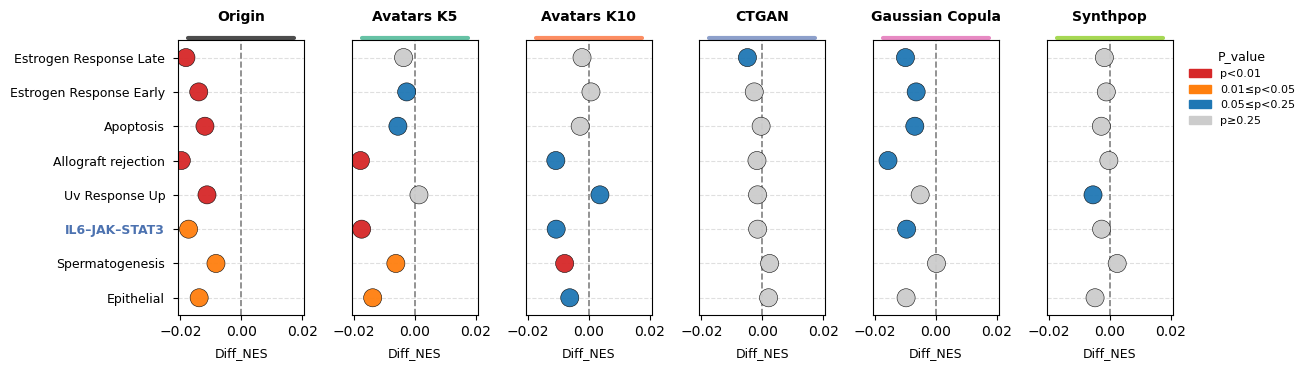

In [5]:
import pandas as pd
import numpy as np
from ssGSEA import ssGSEA_differential
import os


dataset_dict = {}
dataset_dict_nivo = {}
original_data = pd.read_csv("../../Data/original_data.csv", index_col = 0)
dataset_dict["Origin"] = original_data

seed = 3
os.makedirs(f'PBRM1/Seed_{seed}', exist_ok = True)
syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}", f"synthpop_{seed}",f"tvae_{seed}"]
for i, tool in enumerate(syn_datas):
    syn_df = pd.read_csv(f"../../Data/{syn_datas[i]}.csv", index_col = 0)
    dataset_dict[tool] = syn_df

ssGSEA = {}
res_ssGSEA = {
    'Origin': f'PBRM1/Seed_{seed}/Origin.csv',
    f"avatarsk5_{seed}": f'PBRM1/Seed_{seed}/avatarsk5_{seed}.csv',
    f"avatarsk10_{seed}": f'PBRM1/Seed_{seed}/avatarsk10_{seed}.csv',
    f"ctgan_{seed}": f'PBRM1/Seed_{seed}/ctgan_{seed}.csv',
    f"gaussiancopula_{seed}": f'PBRM1/Seed_{seed}/gaussiancopula_{seed}.csv',
    f"synthpop_{seed}": f'PBRM1/Seed_{seed}/synthpop_{seed}.csv',
    f"tvae_{seed}": f'PBRM1/Seed_{seed}/tvae_{seed}.csv',
}

for tool, path in res_ssGSEA.items():
    res = pd.read_csv(path)
    ssGSEA[tool] = res



dataset_metadata = {}
for name, data in dataset_dict.items():
    metadata = pd.DataFrame(
        {"Patient": data.index.tolist(),
         "PBRM1": data['PBRM1'].values.tolist()
        }
    )
    dataset_metadata[name]=metadata
phenotypes =  {"PBRM1": ["MUT","WT"]}

DifferentialAnalysis_ssGSEA = ssGSEA_differential(
    ssGSEA,
    dataset_metadata,
    phenotypes,
    id_col = "Patient",
    term_col = "Term",
    sample_col = "Name",
    nes_col = "NES",
    alpha = 0.05)

plot_dict = {}
names = ['Origin', "Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", 'TVAE']

for i, df in enumerate(DifferentialAnalysis_ssGSEA.values()):
    name = names[i]
    if name == 'TVAE':
        continue # Bỏ qua các dòng code phía dưới và nhảy sang vòng lặp kế tiếp
        
    df_plot = df[['Term', 'P_value', 'Diff_NES']]
    plot_dict[name] = df_plot

DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

or_res = plot_dict['Origin']
ref_pathway_list = or_res[or_res['P_value']<0.05]['Term'].values.tolist()
highlight_pathways = ['HALLMARK_IL6_JAK_STAT3_SIGNALING']

# Call the plotting function
fig, df_used = plot_pathway(
    ssGSEA_comparison=plot_dict,
    ref_pathway_list=ref_pathway_list,
    highlight_pathways=highlight_pathways,
    origin_name = "Origin",
    term_col = "Term",
    pval_col = "P_value",
    diff_col = "Diff_NES",
    figsize=(15,4),
    dataset_colors=DATASET_COLORS,   # <- colored strip theo dataset
    dataset_strip_lw=3.0,            # độ dày strip (tuỳ chỉnh)
    dataset_strip_y=1.01,            # vị trí (axes coords)
    dataset_strip_pad=0.0,           # nâng/hạ thêm nếu cần
    show=True,
    save_path=None
)
# fig.savefig(f'PBRM1/BubblePlot_{seed}.pdf', dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

Processing seed 0...
Processing seed 1...
Processing seed 2...
Processing seed 3...
Processing seed 42...


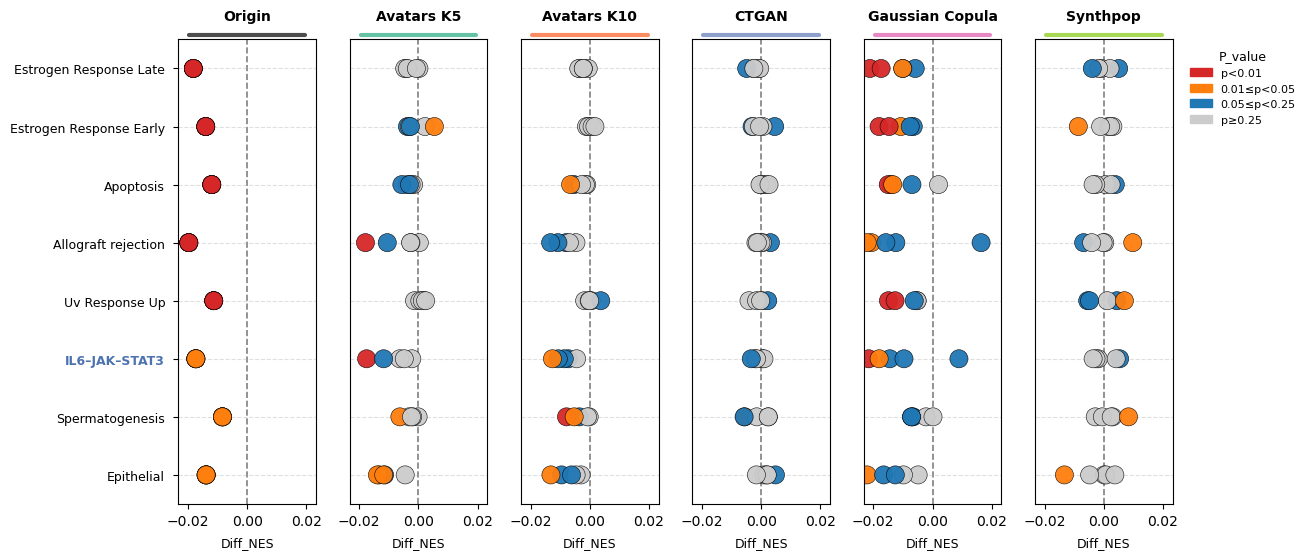

In [7]:
import pandas as pd
import numpy as np
import os
from ssGSEA import ssGSEA_differential
# from plot_pathway_visual import plot_pathway
import matplotlib.pyplot as plt

# seeds to combine
seeds = [0, 1, 2, 3, 42]

# mapping from file/tool keys to display names used in the plot
def display_name_for_tool(tool_key: str) -> str:
    if tool_key == "Origin":
        return "Origin"
    if tool_key.startswith("avatarsk5"):
        return "Avatars K5"
    if tool_key.startswith("avatarsk10"):
        return "Avatars K10"
    if tool_key.startswith("ctgan"):
        return "CTGAN"
    if tool_key.startswith("gaussiancopula"):
        return "Gaussian Copula"
    if tool_key.startswith("synthpop"):
        return "Synthpop"
    if tool_key.startswith("tvae"):
        return "TVAE"
    return tool_key

# display order / colors (same as original)
DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

# Prepare container to collect per-display-name results across seeds
combined_results = {
    "Origin": [],
    "Avatars K5": [],
    "Avatars K10": [],
    "CTGAN": [],
    "Gaussian Copula": [],
    "Synthpop": [],
    "TVAE": [],
}

# load original_data once (used for dataset_metadata)
original_data = pd.read_csv("../../Data/original_data.csv", index_col=0)

for seed in seeds:
    print(f"Processing seed {seed}...")
    # names of files (these include seed in filename)
    syn_datas = [
        f"avatarsk5_{seed}",
        f"avatarsk10_{seed}",
        f"ctgan_{seed}",
        f"gaussiancopula_{seed}",
        f"synthpop_{seed}",
        f"tvae_{seed}",
    ]

    # Build dataset_dict for this seed (used to create metadata)
    dataset_dict = {}
    dataset_dict["Origin"] = original_data
    for syn in syn_datas:
        path = f"../../Data/{syn}.csv"
        if not os.path.exists(path):
            raise FileNotFoundError(f"Expected data file not found: {path}")
        syn_df = pd.read_csv(path, index_col=0)
        dataset_dict[syn] = syn_df

    # Build dataset_metadata for this seed
    dataset_metadata = {}
    for name, data in dataset_dict.items():
        # require the phenotype column 'PBRM1' to exist in each dataframe
        if "PBRM1" not in data.columns:
            raise KeyError(f"PBRM1 column missing in dataset {name} (file for seed {seed})")
        metadata = pd.DataFrame(
            {
                "Patient": data.index.tolist(),
                "PBRM1": data["PBRM1"].values.tolist(),
            }
        )
        dataset_metadata[name] = metadata

    # Read ssGSEA result CSVs for this seed (these are the per-sample/per-term NES outputs)
    ssGSEA = {}
    # file paths expected under PBRM1/Seed_{seed}/
    res_ssGSEA = {
        "Origin": f"PBRM1/Seed_{seed}/Origin.csv",
        f"avatarsk5_{seed}": f"PBRM1/Seed_{seed}/avatarsk5_{seed}.csv",
        f"avatarsk10_{seed}": f"PBRM1/Seed_{seed}/avatarsk10_{seed}.csv",
        f"ctgan_{seed}": f"PBRM1/Seed_{seed}/ctgan_{seed}.csv",
        f"gaussiancopula_{seed}": f"PBRM1/Seed_{seed}/gaussiancopula_{seed}.csv",
        f"synthpop_{seed}": f"PBRM1/Seed_{seed}/synthpop_{seed}.csv",
        f"tvae_{seed}": f"PBRM1/Seed_{seed}/tvae_{seed}.csv",
    }

    for tool_key, path in res_ssGSEA.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"Expected ssGSEA result not found: {path}")
        res = pd.read_csv(path)
        ssGSEA[tool_key] = res

    # Run differential analysis for this seed
    DifferentialAnalysis_ssGSEA = ssGSEA_differential(
        ssGSEA,
        dataset_metadata,
        {"PBRM1": ["MUT", "WT"]},
        id_col="Patient",
        term_col="Term",
        sample_col="Name",
        nes_col="NES",
        alpha=0.05,
    )

    # Collect plotting info: for each tool, extract Term, P_value, Diff_NES and add seed column
    for tool_key, df in DifferentialAnalysis_ssGSEA.items():
        display_name = display_name_for_tool(tool_key)
        # some tools may not be in our display set; skip if not present
        if display_name not in combined_results:
            continue
        # ensure expected columns exist
        if not {"Term", "P_value", "Diff_NES"}.issubset(df.columns):
            raise KeyError(f"Expected Term/P_value/Diff_NES columns in differential result for {tool_key} (seed {seed})")
        df_plot = df[["Term", "P_value", "Diff_NES"]].copy()
        df_plot["seed"] = seed
        combined_results[display_name].append(df_plot)

# Concatenate across seeds for each display dataset
plot_dict = {}
for display_name, parts in combined_results.items():
    if len(parts) == 0:
        # keep an empty dataframe to avoid missing dataset entirely (plot_pathway will skip if no matching terms)
        plot_dict[display_name] = pd.DataFrame(columns=["Term", "P_value", "Diff_NES", "seed"])
    else:
        plot_dict[display_name] = pd.concat(parts, ignore_index=True)

# Remove/skip TVAE from plotting if you want (original code skipped TVAE)
if "TVAE" in plot_dict:
    plot_dict.pop("TVAE", None)

# Build reference pathway list from Origin: any term with p<0.05 in any seed (unique)
or_res = plot_dict.get("Origin")
if or_res is None or or_res.empty:
    raise ValueError("Origin results empty after combining seeds; cannot build ref_pathway_list.")
ref_pathway_list = sorted(set(or_res[or_res["P_value"] < 0.05]["Term"].values.tolist()))

# optionally highlight some pathways
highlight_pathways = ["HALLMARK_IL6_JAK_STAT3_SIGNALING"]

# Call the plotting function: note pval_col is "P_value" as used in combined dataframes
fig, df_used = plot_pathway(
    ssGSEA_comparison=plot_dict,
    ref_pathway_list=ref_pathway_list,
    highlight_pathways=highlight_pathways,
    origin_name="Origin",
    term_col="Term",
    pval_col="P_value",
    diff_col="Diff_NES",
    figsize=(15, 6),
    dataset_colors=DATASET_COLORS,
    dataset_strip_lw=3.0,
    dataset_strip_y=1.01,
    dataset_strip_pad=0.0,
    show=True,
    save_path=None,
)

# If you want to save the figure:
# fig.savefig('PBRM1/BubblePlot_all_seeds.pdf', dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

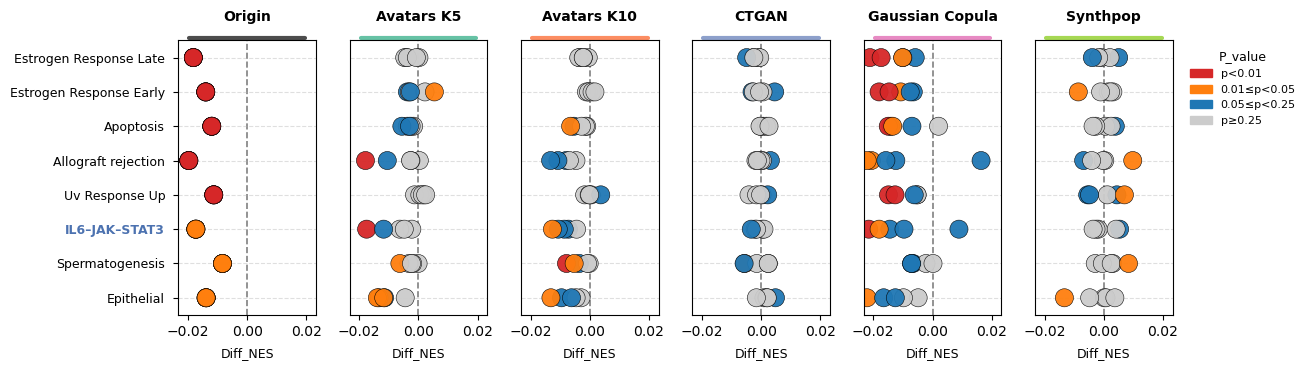

In [9]:
fig, df_used = plot_pathway(
    ssGSEA_comparison=plot_dict,
    ref_pathway_list=ref_pathway_list,
    highlight_pathways=highlight_pathways,
    origin_name="Origin",
    term_col="Term",
    pval_col="P_value",
    diff_col="Diff_NES",
    figsize=(15, 4),
    dataset_colors=DATASET_COLORS,
    dataset_strip_lw=3.0,
    dataset_strip_y=1.01,
    dataset_strip_pad=0.0,
    show=True,
    save_path=None,
)

# If you want to save the figure:
fig.savefig('PBRM1/BubblePlot_all_seeds.pdf', dpi=300, bbox_inches="tight", facecolor="white")
plt.show()